In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from seaborn import color_palette
from sklearn.model_selection import train_test_split

file_path = "C:/Users/Super/PycharmProjects/MSiD/resources/sleep_health_dataset.csv"

df = pd.read_csv(file_path, )

print(f"Size: {df.shape[0]} columns x {df.shape[1]} rows")

df.head(5)

Size: 100000 columns x 32 rows


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,3,0,0.0,32,0,6592,0,4.4,10.7,Morning,Healthy,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,4,0,0.0,33,1,10111,8,4.0,3.0,Neutral,Healthy,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,4,0,2.0,89,1,9222,28,7.8,3.6,Neutral,Both,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,4,0,1.0,52,1,9190,40,4.9,6.7,Morning,Healthy,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,5,40,0.0,72,0,4273,0,7.4,10.4,Neutral,Healthy,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [43]:
# Testing and checking for invalid data
num_data = df.select_dtypes(include=np.number).columns.drop("person_id").tolist()
cat_data = df.select_dtypes(exclude=np.number).columns.tolist()

print(f"Liczba danych ciągłych: {len(num_data)} \nliczba dancyh kategorialnych: {len(cat_data)}")

pd.set_option('display.max_columns', None)
df.describe().round(2)

Liczba danych ciągłych: 23 
liczba dancyh kategorialnych: 8


,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,50000.50,34.71,26.29,6.42,4.87,20.24,20.25,19.84,3.35,38.85,0.60,63.54,0.45,7496.86,14.94,5.73,7.13,66.57,0.56,0.08,20.54,1.20,59.23,0.39
std,28867.66,11.04,4.48,1.27,1.51,3.41,4.25,7.58,1.92,69.40,1.06,44.55,0.50,3460.42,21.39,1.62,3.48,7.23,0.50,0.28,2.90,0.79,22.25,0.49
min,1.00,18.00,16.00,3.00,1.00,10.00,5.00,1.00,0.00,0.00,0.00,2.00,0.00,500.00,0.00,1.00,0.00,45.00,0.00,0.00,15.00,-1.00,0.00,0.00
25%,25000.75,26.00,23.20,5.53,3.80,18.00,17.40,14.00,2.00,0.00,0.00,30.00,0.00,5045.00,0.00,4.80,4.70,62.00,0.00,0.00,18.50,0.67,44.20,0.00
50%,50000.50,33.00,26.30,6.36,4.90,20.30,20.30,19.00,3.00,0.00,0.00,51.00,0.00,7442.00,0.00,5.80,7.40,67.00,1.00,0.00,20.50,1.20,60.40,0.00
75%,75000.25,42.00,29.30,7.27,6.00,22.60,23.20,25.00,5.00,80.00,1.00,84.00,1.00,9887.00,30.00,6.80,9.70,71.00,1.00,0.00,22.50,1.74,75.80,1.00
max,100000.00,69.00,45.00,10.50,10.00,30.00,30.00,58.00,8.00,400.00,6.00,180.00,1.00,20000.00,116.00,10.00,18.00,99.00,1.00,1.00,28.00,3.00,100.00,1.00


Text(0, 0.5, 'Liczność')

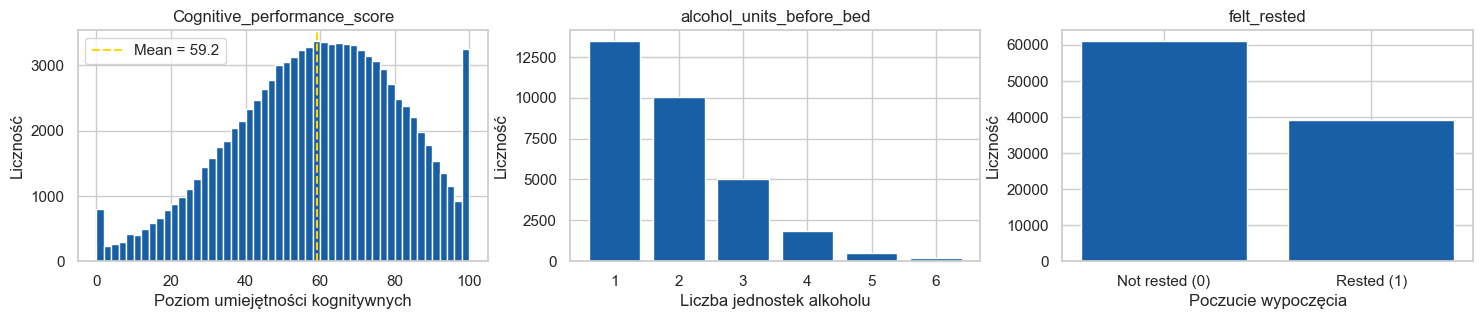

In [44]:
fig = plt.figure(figsize=(18, 3))
gs = GridSpec(1, 3, figure=fig)

# 1. Histogram cognitive_performance_score
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df['cognitive_performance_score'], bins=50, color='#185FA5', edgecolor='white')
ax1.axvline(df['cognitive_performance_score'].mean(), color='gold', linestyle='--', linewidth=1.5, label=f'Mean = {df["cognitive_performance_score"].mean():.1f}')
ax1.set_title('Cognitive_performance_score')
ax1.set_ylabel('Liczność')
ax1.set_xlabel('Poziom umiejętności kognitywnych')
ax1.legend()

# 2. Wykres spożycia alkoholu przed snem
ax2 = fig.add_subplot(gs[0, 1])
order = [1,2,3,4,5,6]
ax2.bar(order, df['alcohol_units_before_bed'].value_counts().reindex(order), color='#185FA5', edgecolor='white')
ax2.set_title('alcohol_units_before_bed')
ax2.set_xlabel('Liczba jednostek alkoholu')
ax2.set_ylabel('Liczność')

# 3. Wykres wypoczęcia po przebudzeniu
ax3 = fig.add_subplot(gs[0, 2])
rested_counts = df['felt_rested'].value_counts().sort_index()
order = ['Not rested (0)', 'Rested (1)']
ax3.bar(order, rested_counts, color='#185FA5', edgecolor='white')
ax3.set_title('felt_rested')
ax3.set_xlabel('Poczucie wypoczęcia')
ax3.set_ylabel('Liczność')

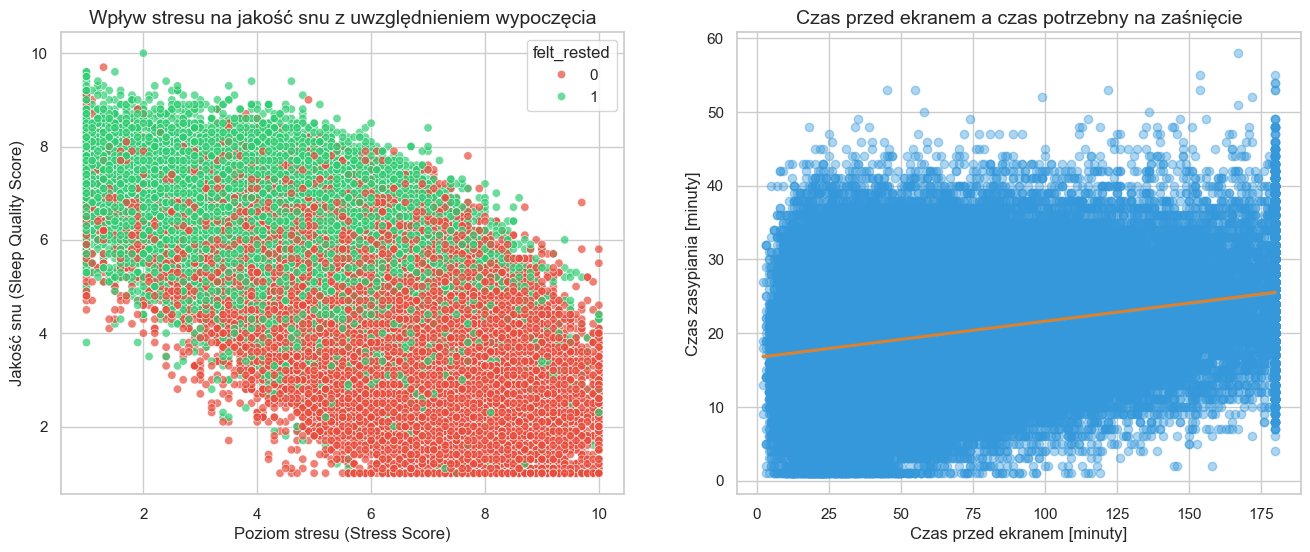

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# wykres jakości snu względem wypoczęcia
sns.scatterplot(
    data=df,
    x='stress_score',
    y='sleep_quality_score',
    hue='felt_rested',
    palette={0: '#e74c3c', 1: '#2ecc71'},
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title('Wpływ stresu na jakość snu z uwzględnieniem wypoczęcia', fontsize=14)
axes[0].set_xlabel('Poziom stresu (Stress Score)', fontsize=12)
axes[0].set_ylabel('Jakość snu (Sleep Quality Score)', fontsize=12)

# wykres zależności sleep latency od screen-time'u
sns.regplot(
    data=df,
    x='screen_time_before_bed_mins',
    y='sleep_latency_mins',
    scatter_kws={'alpha': 0.4, 'color': '#3498db'},
    line_kws={'color': '#e67e22', 'linewidth': 2},
    ax=axes[1]
)
axes[1].set_title('Czas przed ekranem a czas potrzebny na zaśnięcie', fontsize=14)
axes[1].set_xlabel('Czas przed ekranem [minuty]', fontsize=12)
axes[1].set_ylabel('Czas zasypiania [minuty]', fontsize=12)

plt.show()

In [46]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['felt_rested'])

train_df.info()
train_df.describe().round(2)

<class 'pandas.DataFrame'>
Index: 80000 entries, 31687 to 13273
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_id                    80000 non-null  int64  
 1   age                          80000 non-null  int64  
 2   gender                       80000 non-null  str    
 3   occupation                   80000 non-null  str    
 4   bmi                          80000 non-null  float64
 5   country                      80000 non-null  str    
 6   sleep_duration_hrs           80000 non-null  float64
 7   sleep_quality_score          80000 non-null  float64
 8   rem_percentage               80000 non-null  float64
 9   deep_sleep_percentage        80000 non-null  float64
 10  sleep_latency_mins           80000 non-null  int64  
 11  wake_episodes_per_night      80000 non-null  int64  
 12  caffeine_mg_before_bed       80000 non-null  int64  
 13  alcohol_units_before_bed    

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00
mean,50080.90,34.71,26.30,6.42,4.87,20.24,20.26,19.84,3.35,38.78,0.60,63.53,0.45,7497.34,14.93,5.73,7.14,66.58,0.56,0.08,20.54,1.20,59.24,0.39
std,28871.61,11.03,4.48,1.28,1.51,3.41,4.25,7.59,1.92,69.26,1.06,44.56,0.50,3456.95,21.40,1.62,3.48,7.22,0.50,0.28,2.90,0.79,22.25,0.49
min,1.00,18.00,16.00,3.00,1.00,10.00,5.00,1.00,0.00,0.00,0.00,2.00,0.00,500.00,0.00,1.00,0.00,45.00,0.00,0.00,15.00,-1.00,0.00,0.00
25%,25062.75,26.00,23.20,5.53,3.80,18.00,17.40,14.00,2.00,0.00,0.00,30.00,0.00,5043.00,0.00,4.80,4.70,62.00,0.00,0.00,18.50,0.67,44.20,0.00
50%,50147.50,33.00,26.30,6.36,4.90,20.30,20.30,19.00,3.00,0.00,0.00,51.00,0.00,7440.50,0.00,5.80,7.40,67.00,1.00,0.00,20.50,1.20,60.40,0.00
75%,75043.25,42.00,29.30,7.27,6.00,22.60,23.20,25.00,5.00,80.00,1.00,84.00,1.00,9886.00,30.00,6.80,9.70,71.00,1.00,0.00,22.50,1.74,75.80,1.00
max,100000.00,69.00,45.00,10.50,10.00,30.00,30.00,58.00,8.00,400.00,6.00,180.00,1.00,20000.00,116.00,10.00,18.00,99.00,1.00,1.00,28.00,3.00,100.00,1.00


In [47]:
cat_cols = train_df.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

print("Podsumowanie cech kategorialnych w zbiorze treningowym:\n")

for col in cat_cols:
    unique_count = train_df[col].nunique()
    print(f"Cecha: **{col}** | Unikalnych wartości: {unique_count}")

    value_counts = train_df[col].value_counts()
    proportions = train_df[col].value_counts(normalize=True) * 100

    summary_df = pd.DataFrame({
        'Liczebność': value_counts,
        'Procent (%)': proportions.round(2)
    })
    print(summary_df.head())
    print("-" * 30)

Podsumowanie cech kategorialnych w zbiorze treningowym:

Cecha: **gender** | Unikalnych wartości: 3
        Liczebność  Procent (%)
gender                         
Female       40118        50.15
Male         38298        47.87
Other         1584         1.98
------------------------------
Cecha: **occupation** | Unikalnych wartości: 12
                   Liczebność  Procent (%)
occupation                                
Student                 11810        14.76
Software Engineer        9680        12.10
Nurse                    8082        10.10
Teacher                  6497         8.12
Manager                  6403         8.00
------------------------------
Cecha: **country** | Unikalnych wartości: 15
         Liczebność  Procent (%)
country                         
USA           15995        19.99
India         14374        17.97
Japan          6468         8.09
UK             6364         7.95
Brazil         5663         7.08
------------------------------
Cecha: **chronotype** 

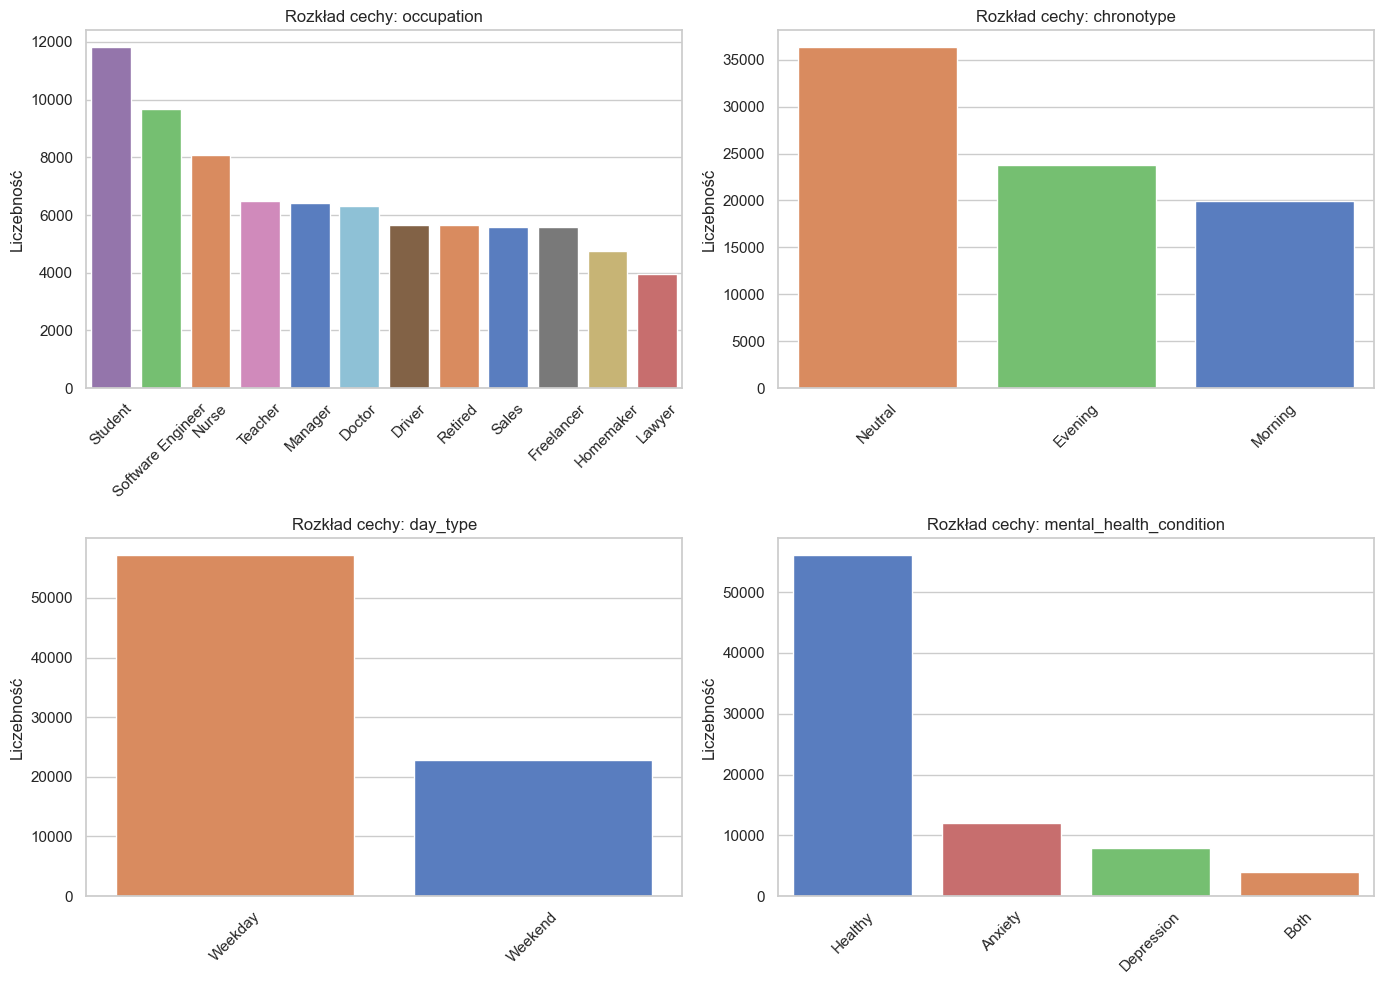

In [48]:
features_to_plot = ['occupation', 'chronotype', 'day_type', 'mental_health_condition']

# Filtrujemy tylko te, które faktycznie istnieją w naszym zbiorze
features_to_plot = [f for f in features_to_plot if f in cat_cols]

if features_to_plot:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    sns.set_theme(style="whitegrid")

    for i, feature in enumerate(features_to_plot):
        row = i // 2
        col = i % 2

        # Rysujemy countplot (liczebność klas)
        sns.countplot(
            data=train_df,
            x=feature,
            hue=feature,
            palette='muted',
            legend=False,
            ax=axes[row, col],
            order=train_df[feature].value_counts().index
        )
        axes[row, col].set_title(f'Rozkład cechy: {feature}', fontsize=12)
        axes[row, col].tick_params(axis='x', rotation=45) # Obrót etykiet osi X
        axes[row, col].set_ylabel('Liczebność')
        axes[row, col].set_xlabel('')

    plt.tight_layout()
    plt.show()

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]